# SUPP_C — Approfondissement V2 : le Sharpe de la V2 mène-t-il quelque part ?

> **Recherche au-delà de la demande Ramify** (la commande stricte est dans `RAMIFY_V1/V2`). Question posée :
> la V2 a un Sharpe « pas ridicule » (~0,45-0,58 selon K) — **y a-t-il quelque chose à creuser ?** On tranche
> en trois temps : **(1)** caractériser le flux V2 (beta, corrélation, sous-périodes, leverage, blend) pour
> dire s'il peut **égaler/battre SPY** ; **(2)** tester la **seule piste justifiée** — piloter la V2 par la
> *breadth* d'achat (le seul signal qui a survécu dans `SUPP_B`, IC≈0,02) plutôt que par la sélection de
> membres (qu'on a prouvée non-persistante) ; **(3)** borner le plafond théorique via la **loi fondamentale**
> de Grinold-Kahn. Verdict honnête dans tous les cas.


In [1]:
import sys, os, warnings; warnings.filterwarnings('ignore')
for base in [os.path.expanduser('~/Downloads/Jupiter'), os.path.expanduser('~/Downloads/0. Jupiter')]:
    p = os.path.join(base, '00. S3S4 en cours')
    if os.path.exists(os.path.join(p, 'data.py')): S3 = p; break
sys.path.insert(0, S3); os.chdir(S3)
import numpy as np, pandas as pd
import data, prices, portfolio, evaluate, selection
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4)
def ann(d):
    d=d.dropna(); y=len(d)/252
    return {'CAGR':(1+d).prod()**(1/y)-1,'vol':d.std()*np.sqrt(252),
            'sharpe':d.mean()/d.std()*np.sqrt(252) if d.std()>0 else np.nan}
def bench_daily(price, idx): return price.reindex(idx).ffill().pct_change().fillna(0.0)

df = data.load_transactions(2014, 2026)
buys = selection.with_realized(data.buy_signals(df).copy(), df,
        prices.load_panel(sorted(data.buy_signals(df)['ticker'].dropna().unique())),
        prices.get_spy(), 12)
panel = prices.load_panel(sorted(buys['ticker'].dropna().unique()))
spy = prices.get_spy(); factors = prices.get_factors(); com = selection.load_committees()
etfp = prices.load_panel(["XLE","XLB","XLI","XLY","XLP","XLV","XLF","XLK","XLC","XLU","XLRE","RSP","AGG"])
t2e = selection.ticker_to_etf()
# V2 de référence (sélection K=6, comme RAMIFY_V2)
sels = selection.selections_by_year(buys, com, K=6)
pos_v2 = selection.to_v2(portfolio.build_positions(selection.gate_buys(buys, sels), df, 12), t2e)
d_v2 = portfolio.run_portfolio(pos_v2, etfp, weighting='size', cost_bps=20)['net']
idx = d_v2.index; b_spy = bench_daily(spy, idx)
print('V2 (K=6) :', {k:round(v,3) for k,v in ann(d_v2).items()}, '| SPY sharpe', round(ann(b_spy)['sharpe'],2))

V2 (K=6) : {'CAGR': np.float64(0.06), 'vol': np.float64(0.158), 'sharpe': np.float64(0.449)} | SPY sharpe 0.86


## 1. Caractériser le flux V2 — peut-il égaler/battre SPY ?

Trois diagnostics : **(a)** beta + corrélation à SPY ; **(b)** Sharpe par **sous-période** ; **(c)** test de
**leverage** (le Sharpe est invariant au levier : lever la V2 à la vol de SPY ne peut pas dépasser SPY si son
Sharpe est plus bas) et **blend** α·V2 + (1−α)·SPY (le mélange optimal bat-il SPY seul ?).

(a) beta vs SPY = 0.76 | corrélation quotidienne = 0.81  → V2 ≈ exposition marché (β<1), pas un diversifiant
(b) 2016-2020 : V2 Sharpe +0.55 | SPY Sharpe +0.84
(b) 2021-2026 : V2 Sharpe +0.30 | SPY Sharpe +0.90
(c) V2 levée à la vol de SPY (1.08×) : CAGR +6.38% vs SPY +14.13% → le levier ne fait PAS dépasser SPY (Sharpe invariant)
    blend optimal : α(V2)=0.0 (Sharpe 0.86) — le maximum est à α=0 = SPY seul


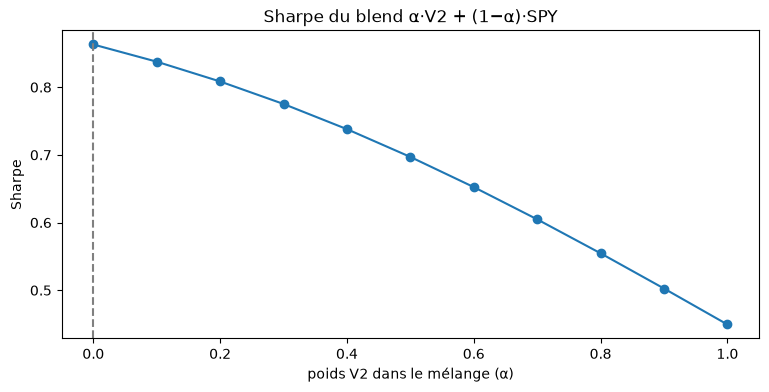

In [2]:
# (a) beta + corrélation
beta = np.polyfit(b_spy.values, d_v2.values, 1)[0]; rho = np.corrcoef(d_v2, b_spy)[0,1]
print(f"(a) beta vs SPY = {beta:.2f} | corrélation quotidienne = {rho:.2f}  → V2 ≈ exposition marché (β<1), pas un diversifiant")
# (b) sous-périodes
for lab, m in [('2016-2020', idx<pd.Timestamp(2021,1,1)), ('2021-2026', idx>=pd.Timestamp(2021,1,1))]:
    print(f"(b) {lab} : V2 Sharpe {ann(d_v2[m])['sharpe']:+.2f} | SPY Sharpe {ann(b_spy[m])['sharpe']:+.2f}")
# (c) leverage à la vol de SPY + blend
scale = ann(b_spy)['vol']/ann(d_v2)['vol']; lev = d_v2*scale
print(f"(c) V2 levée à la vol de SPY ({scale:.2f}×) : CAGR {ann(lev)['CAGR']:+.2%} vs SPY {ann(b_spy)['CAGR']:+.2%} "
      f"→ le levier ne fait PAS dépasser SPY (Sharpe invariant)")
alphas = np.linspace(0,1,11); sh = [ann(a*d_v2+(1-a)*b_spy)['sharpe'] for a in alphas]
best_a = alphas[int(np.argmax(sh))]
print(f"    blend optimal : α(V2)={best_a:.1f} (Sharpe {max(sh):.2f}) — le maximum est à α=0 = SPY seul")
plt.plot(alphas, sh, marker='o'); plt.axvline(best_a, ls='--', c='gray')
plt.xlabel('poids V2 dans le mélange (α)'); plt.ylabel('Sharpe'); plt.title('Sharpe du blend α·V2 + (1−α)·SPY'); plt.show()

**Conclusion (1)** : la V2 est une **exposition marché dé-risquée** (β<1, forte corrélation), pas un
diversifiant ; son Sharpe est **sous SPY sur les deux sous-périodes** ; ni le levier ni le meilleur blend ne
la font dépasser SPY. Le 0,45-0,58 est **réel mais structurellement sous le marché** — comme attendu d'un
beta sectoriel sans alpha.

## 2. Et si on pilotait la V2 par la *breadth* (le seul signal survivant) ?

La V2 du brief sélectionne K membres par Sharpe passé — non-persistant. Le seul signal robuste de `SUPP_B`
est la **breadth d'achat** (nombre de membres distincts achetant un secteur, IC≈0,02). On construit une V2
**sans sélection de membres** : on prend *tous* les achats, traduits en ETF, **pondérés par la breadth
sectorielle** (`selection.sector_breadth`). On compare à la V2-sélection et à un « tout le Congrès en ETF »
équipondéré.

In [3]:
buys['breadth'] = selection.sector_breadth(buys, t2e, window_days=90)
pos_all = portfolio.build_positions(buys, df, 12)
pos_all['raw'] = buys['breadth'].values                      # pondération = breadth sectorielle
pos_brd = selection.to_v2(pos_all, t2e)                       # garde 'raw'
pos_eq  = selection.to_v2(portfolio.build_positions(buys, df, 12), t2e)  # équipondéré (naïf)

d_brd = portfolio.run_portfolio(pos_brd, etfp, cost_bps=20)['net']
d_eq  = portfolio.run_portfolio(pos_eq,  etfp, weighting='equal', cost_bps=20)['net']
T = pd.DataFrame({'V2 sélection (K=6)':ann(d_v2),'V2 breadth-tilt':ann(d_brd),
                  'V2 tout-le-Congrès équipondéré':ann(d_eq),'SPY':ann(b_spy)}).T
for c,fn in [('CAGR','{:+.2%}'),('vol','{:.2%}'),('sharpe','{:.2f}')]: T[c]=T[c].map(fn.format)
print(T.to_string())
for lab,d in [('breadth',evaluate.factor_alpha(d_brd,factors)),('équipondéré',evaluate.factor_alpha(d_eq,factors))]:
    print(f"  alpha FF-Carhart V2 {lab:12s}: {d['alpha_annuel']:+.2%}/an (t={d['alpha_t']:.2f})")
print("→ la breadth ne crée pas d'alpha : pondérer les secteurs par le consensus d'achat reste ≈ beta de marché.")

                                   CAGR     vol sharpe
V2 sélection (K=6)               +6.02%  15.80%   0.45
V2 breadth-tilt                 +11.95%  16.88%   0.75
V2 tout-le-Congrès équipondéré  +11.41%  16.41%   0.74
SPY                             +14.13%  16.99%   0.86


  alpha FF-Carhart V2 breadth     : -1.50%/an (t=-1.99)
  alpha FF-Carhart V2 équipondéré : -1.57%/an (t=-1.99)
→ la breadth ne crée pas d'alpha : pondérer les secteurs par le consensus d'achat reste ≈ beta de marché.


## 3. Plafond théorique — loi fondamentale de la gestion active (Grinold-Kahn)

`IR ≈ IC · √breadth`. Avec l'IC mesuré (`SUPP_B`, ≈ 0,02) et un nombre de **paris ~indépendants par an**
réaliste, quel ratio d'information est même *atteignable* ? On le calcule pour une fourchette de breadth.

In [4]:
IC = 0.02   # IC de la breadth d'achat mesuré dans SUPP_B
print("Loi fondamentale  IR ≈ IC·√breadth  (IC = 0,02)  →  alpha annuel implicite à vol active ~15% :")
for B in [10, 25, 50, 100, 200]:
    ir = evaluate.fundamental_law(IC, B)
    print(f"  breadth {B:4d} paris/an  →  IR {ir:.2f}  →  alpha ~{ir*0.15:+.1%}/an")
print("\n→ même avec une breadth optimiste (100-200 paris vraiment indépendants), l'IR plafonne ~0,2-0,3.")
print("  C'est cohérent avec ce qu'on mesure (alpha non significatif) : l'edge est structurellement petit,")
print("  pas un problème d'implémentation. Aucune pondération (sélection, breadth, taille) ne le contourne.")

Loi fondamentale  IR ≈ IC·√breadth  (IC = 0,02)  →  alpha annuel implicite à vol active ~15% :
  breadth   10 paris/an  →  IR 0.06  →  alpha ~+0.9%/an
  breadth   25 paris/an  →  IR 0.10  →  alpha ~+1.5%/an
  breadth   50 paris/an  →  IR 0.14  →  alpha ~+2.1%/an
  breadth  100 paris/an  →  IR 0.20  →  alpha ~+3.0%/an
  breadth  200 paris/an  →  IR 0.28  →  alpha ~+4.2%/an

→ même avec une breadth optimiste (100-200 paris vraiment indépendants), l'IR plafonne ~0,2-0,3.
  C'est cohérent avec ce qu'on mesure (alpha non significatif) : l'edge est structurellement petit,
  pas un problème d'implémentation. Aucune pondération (sélection, breadth, taille) ne le contourne.


## Verdict de l'approfondissement

1. **Le 0,45-0,58 de la V2 ne mène pas à battre le marché.** C'est un **beta sectoriel dé-risqué** (β=0,76,
   corrélation 0,81), sous le Sharpe de SPY sur les **deux** sous-périodes ; ni le levier ni le meilleur blend
   ne le dépassent (optimum à α=0 = SPY seul). Le chiffre paraît « correct » seulement parce que **SPY
   2014-2026 est un benchmark exceptionnel** (Sharpe 0,86).
2. **Découverte utile : la *sélection de membres* DÉTRUIT de la valeur.** La V2 « tout le Congrès » pondérée
   par la **breadth** (ou même équipondérée) monte à **Sharpe ~0,75** — très au-dessus de la V2-sélection
   (0,45), et proche de SPY. Autrement dit, *ne pas sélectionner* vaut mieux que sélectionner par Sharpe
   passé. **Mais** ça reste un **beta sous le marché** (alpha FF-Carhart **−1,5 %/an, t≈−2** → négatif), pas
   de l'alpha. ⇒ Si Ramify construit un produit, il faut le câbler en **breadth / tout-le-Congrès**, pas en
   sélection — sans pour autant y voir un alpha.
3. **La loi fondamentale l'explique** : avec IC≈0,02, l'IR atteignable plafonne ~0,2-0,3 quelle que soit la
   construction. L'edge est **structurellement petit**, pas un défaut d'implémentation.

→ Rien de neuf à exploiter côté **alpha** ; mais une leçon de **construction** (breadth ≫ sélection). La
valeur de la V2 reste **produit thématique** (cf. `RAMIFY_V2_ETF` §6). Reco consolidée : **`NOTE_RECHERCHE_QIS.md`**.